In [1]:
import os
import random
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from Fastkan import FastKAN

In [2]:
number_of_primitives = 3
visible_range = True#Use False to select entire spectrum
include_shadows = False
no_of_epochs = 30
#Visible range of pavia dataset has 66 bands and full spectrum has 103 bands
no_of_bands = 66 if visible_range else 103
output_classes = 9 if include_shadows else 8

In [3]:
hsi = scipy.io.loadmat("PaviaU.mat")
image = hsi["paviaU"]

gt = scipy.io.loadmat("PaviaU_gt.mat")
index = gt["paviaU_gt"]
image  =image[:, :, :66]

print(image.shape)
print(index.shape)

(610, 340, 66)
(610, 340)


In [4]:
#Normalizing the image
max_val = np.max(image)
normalized_image = np.divide(image, max_val)

In [5]:
image_for_training = normalized_image[:,:,:no_of_bands]
print(image_for_training.shape)

(610, 340, 66)


In [6]:
x = []
for i in range(len(image_for_training)):
    for j in range(len(image_for_training[0])):
        if (index[i][j] == 0) or (index[i][j] == 9 and (not include_shadows)): #Ignoring all unclassified pixels
            continue
        x.append(image_for_training[i][j])

x = np.asarray(x,dtype=np.float32)
print(x.shape)

(41829, 66)


In [7]:
y = []

for i in range(len(image)):
    for j in range(len(image[0])):
        if index[i][j] == 0 or \
           (index[i][j] == 9 and (not include_shadows)):
            continue

        y.append(index[i][j]-1)

y = np.asarray(y , dtype=np.int64)
y.shape

(41829,)

In [8]:
class ColorFastKAN(nn.Module):

    def __init__( self, no_of_bands,number_of_primitives,output_classes,):
        super().__init__()
        self.primitives = nn.ModuleList([
            FastKAN(
                layers_hidden=[no_of_bands, 1])
            for _ in range(number_of_primitives)
        ])
        self.classifier_kan = FastKAN(layers_hidden =[number_of_primitives,output_classes], )

    def forward(self, x):
        primitive_outputs = [
            primitive(x)
            for primitive in self.primitives]
        merged = torch.cat(primitive_outputs ,dim=1)
        kan_logits = self.classifier_kan(merged)
        return kan_logits
model = ColorFastKAN(no_of_bands=no_of_bands,number_of_primitives=number_of_primitives,output_classes=output_classes)

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = model.to(device)

Using device: cpu


In [10]:

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

cie_trainable = False # cie initialized primitives are frozen #PUT TRUE in case of CIE Initialized primitives are Trainable
cie = pd.read_csv(
    "ciexyz.txt",
    sep=r"\s+",
    header=None,
    names=["wavelength", "X", "Y", "Z"]
)

print(cie.head())
cie_wavelength = cie["wavelength"].values

cie_x_orig = cie["X"].values
cie_y_orig = cie["Y"].values
cie_z_orig = cie["Z"].values

pavia_wavelength = np.linspace(430, 860, no_of_bands)

fx = interp1d(
    cie_wavelength,
    cie_x_orig,
    bounds_error=False,
    fill_value=0
)

fy = interp1d(
    cie_wavelength,
    cie_y_orig,
    bounds_error=False,
    fill_value=0
)

fz = interp1d(
    cie_wavelength,
    cie_z_orig,
    bounds_error=False,
    fill_value=0
)

cie_x = fx(pavia_wavelength)
cie_y = fy(pavia_wavelength)
cie_z = fz(pavia_wavelength)


cie_x = cie_x / np.max(cie_x)
cie_y = cie_y / np.max(cie_y)
cie_z = cie_z / np.max(cie_z)

cie_weights = [cie_x, cie_y , cie_z]

with torch.no_grad():
  for primitive_no in range(number_of_primitives):
   cie_weight = torch.tensor(cie_weights[primitive_no],dtype=torch.float32,device=device).reshape(1 , no_of_bands)

   primitive_layer = (model.primitives[primitive_no].layers[0])
   primitive_layer.base_linear.weight.copy_(cie_weight)
   primitive_layer.base_linear.bias.zero_()

for primitive in model.primitives:
  for parameter in primitive.parameters():
     parameter.requires_grad = cie_trainable

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda parameter: parameter.requires_grad,model.parameters()))

print("CIE weights loaded successfully")
print("CIE primitives:" , "Trainable" if cie_trainable  else "Non-trainable")


   wavelength       X       Y       Z
0         380  0.0014  0.0000  0.0065
1         381  0.0015  0.0000  0.0070
2         382  0.0016  0.0000  0.0077
3         383  0.0018  0.0001  0.0085
4         384  0.0020  0.0001  0.0094
CIE weights loaded successfully
CIE primitives: Non-trainable


In [11]:
print(model)

ColorFastKAN(
  (primitives): ModuleList(
    (0-2): 3 x FastKAN(
      (layers): ModuleList(
        (0): Fast_KANLinear(
          (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True, bias=True)
          (rbf): RadialBasisFunction()
          (spline_linear): SplineLinear(in_features=528, out_features=1, bias=False)
          (base_linear): Linear(in_features=66, out_features=1, bias=True)
        )
      )
    )
  )
  (classifier_kan): FastKAN(
    (layers): ModuleList(
      (0): Fast_KANLinear(
        (layernorm): LayerNorm((3,), eps=1e-05, elementwise_affine=True, bias=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=24, out_features=8, bias=False)
        (base_linear): Linear(in_features=3, out_features=8, bias=True)
      )
    )
  )
)


In [12]:
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = model.to(device)

summary(
    model,
    input_size=(1, no_of_bands))

x_tensor = torch.tensor( x,dtype=torch.float32)

y_tensor = torch.tensor( y,dtype=torch.long)

batch_size = 32

dataset = TensorDataset(x_tensor,y_tensor)

train_loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

loss_history = []
accuracy_history = []

for epoch in range(no_of_epochs):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()

        output = model(batch_x)

        loss = criterion(output,batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        predictions = torch.argmax(output,dim=1)

        total_correct += ( predictions == batch_y).sum().item()

        total_samples += batch_y.size(0)

    epoch_loss = total_loss / total_samples

    epoch_accuracy = (total_correct / total_samples
    )

    loss_history.append(
        epoch_loss
    )

    accuracy_history.append(
        epoch_accuracy
    )

    print(
        f"Epoch [{epoch+1}/{no_of_epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Using device: cpu
Epoch [1/30] | Loss: 1.4929 | Accuracy: 0.4702
Epoch [2/30] | Loss: 1.2158 | Accuracy: 0.5521
Epoch [3/30] | Loss: 1.1603 | Accuracy: 0.5773
Epoch [4/30] | Loss: 1.1292 | Accuracy: 0.5925
Epoch [5/30] | Loss: 1.1100 | Accuracy: 0.6006
Epoch [6/30] | Loss: 1.0973 | Accuracy: 0.6070
Epoch [7/30] | Loss: 1.0887 | Accuracy: 0.6088
Epoch [8/30] | Loss: 1.0823 | Accuracy: 0.6119
Epoch [9/30] | Loss: 1.0778 | Accuracy: 0.6133
Epoch [10/30] | Loss: 1.0743 | Accuracy: 0.6149
Epoch [11/30] | Loss: 1.0713 | Accuracy: 0.6154
Epoch [12/30] | Loss: 1.0692 | Accuracy: 0.6153
Epoch [13/30] | Loss: 1.0678 | Accuracy: 0.6160
Epoch [14/30] | Loss: 1.0666 | Accuracy: 0.6168
Epoch [15/30] | Loss: 1.0653 | Accuracy: 0.6173
Epoch [16/30] | Loss: 1.0643 | Accuracy: 0.6169
Epoch [17/30] | Loss: 1.0638 | Accuracy: 0.6176
Epoch [18/30] | Loss: 1.0630 | Accuracy: 0.6177
Epoch [19/30] | Loss: 1.0626 | Accuracy: 0.6186
Epoch [20/30] | Loss: 1.0621 | Accuracy: 0.6182
Epoch [21/30] | Loss: 1.0619 | 

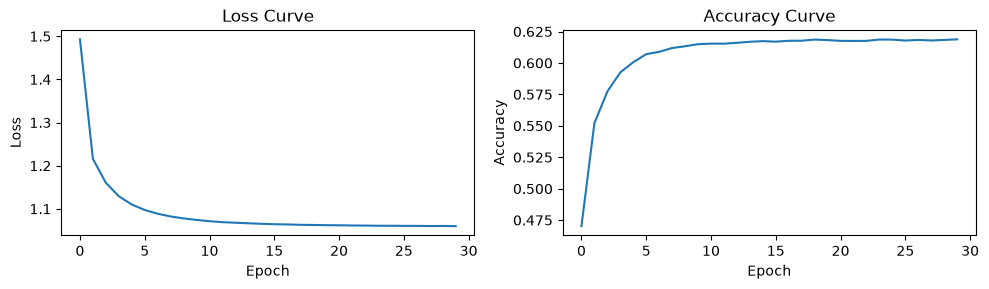

In [13]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [14]:
wavelength = np.linspace(430, 860, 66) #430 - 860 is range of paviaU dataset and 103 is number of bands
wavelength_int = wavelength.astype(int)
print(wavelength_int)

[430 436 443 449 456 463 469 476 482 489 496 502 509 516 522 529 535 542
 549 555 562 568 575 582 588 595 602 608 615 621 628 635 641 648 654 661
 668 674 681 688 694 701 707 714 721 727 734 740 747 754 760 767 774 780
 787 793 800 807 813 820 826 833 840 846 853 860]


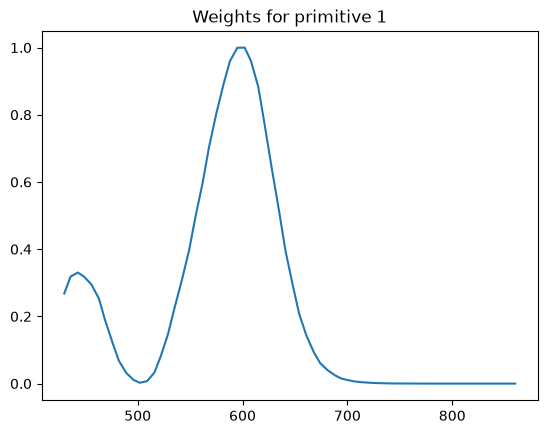

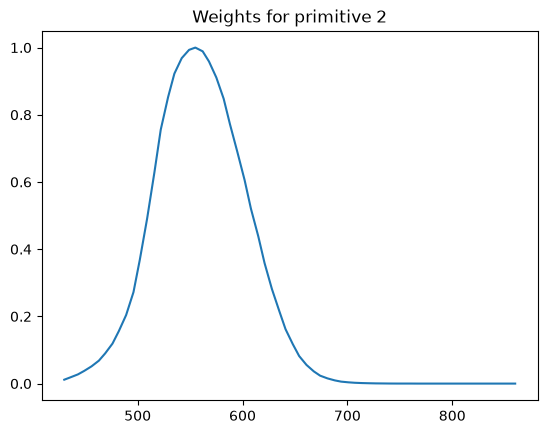

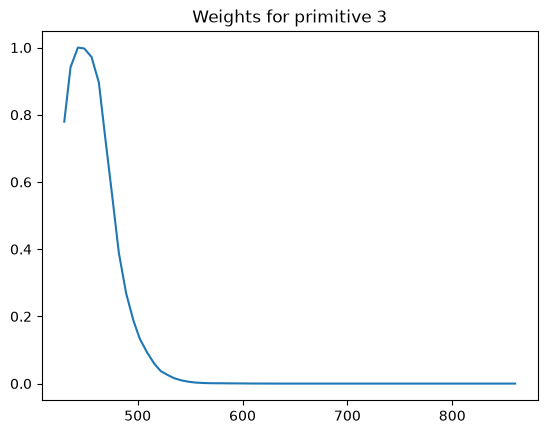

In [15]:
primitive_curves = []

for primitive_no in range(number_of_primitives):

    p = (model.primitives[primitive_no].layers[0] .base_linear.weight .detach().cpu().numpy().flatten())

    primitive_curves.append(p)

    plt.plot(wavelength_int[:no_of_bands],p)

    plt.title(f"Weights for primitive {primitive_no + 1}")

    plt.show()

In [16]:
for i, primitive in enumerate(model.primitives):

    w = (primitive.layers[0].base_linear.weight.detach().cpu().numpy())
    print(i + 1,f"primitive_{i + 1}", w[0, 0])

1 primitive_1 0.26820973
2 primitive_2 0.011601606
3 primitive_3 0.77962303


In [17]:
for i, (name, parameter) in enumerate(model.named_parameters()):
    if parameter.requires_grad:
        print(i, name, parameter.shape)

15 classifier_kan.layers.0.layernorm.weight torch.Size([3])
16 classifier_kan.layers.0.layernorm.bias torch.Size([3])
17 classifier_kan.layers.0.spline_linear.weight torch.Size([8, 24])
18 classifier_kan.layers.0.base_linear.weight torch.Size([8, 3])
19 classifier_kan.layers.0.base_linear.bias torch.Size([8])


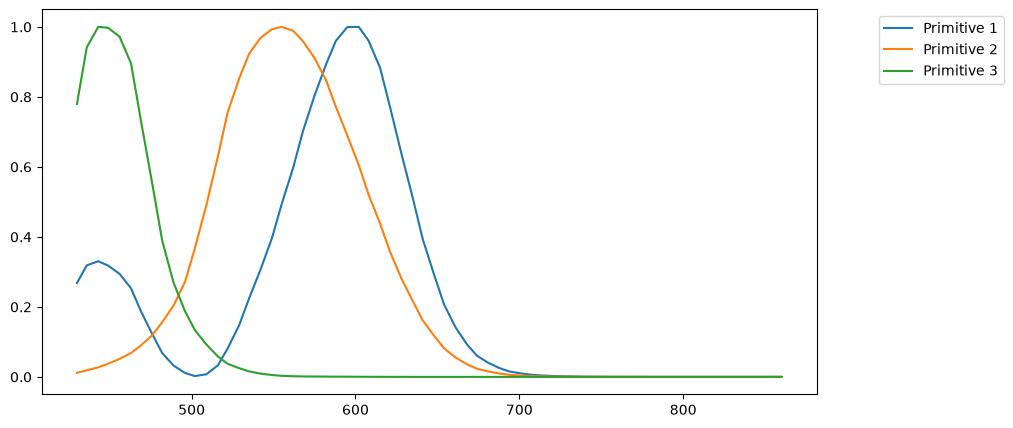

In [18]:
plt.figure(figsize=(10, 5))

for primitive_no in range(number_of_primitives):

    plt.plot(wavelength_int[:no_of_bands],primitive_curves[primitive_no],label=f"Primitive {primitive_no + 1}")
plt.legend(bbox_to_anchor=(1.25, 1))
plt.show()


In [19]:
model_name = (
    f'{no_of_bands}bands_'f'{number_of_primitives}primitives_' f'{"with_shadow" if include_shadows else "without_shadow"}_' f'fastkan_CIE_NT__init')

In [20]:
print(model_name)

66bands_3primitives_without_shadow_fastkan_CIE_NT__init


In [21]:
torch.save(model.state_dict(), f"{model_name}.pth")

In [22]:
model = ColorFastKAN(
    no_of_bands,
    number_of_primitives,
    output_classes
)

model.load_state_dict(torch.load(f"{model_name}.pth"))
model.eval()

ColorFastKAN(
  (primitives): ModuleList(
    (0-2): 3 x FastKAN(
      (layers): ModuleList(
        (0): Fast_KANLinear(
          (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True, bias=True)
          (rbf): RadialBasisFunction()
          (spline_linear): SplineLinear(in_features=528, out_features=1, bias=False)
          (base_linear): Linear(in_features=66, out_features=1, bias=True)
        )
      )
    )
  )
  (classifier_kan): FastKAN(
    (layers): ModuleList(
      (0): Fast_KANLinear(
        (layernorm): LayerNorm((3,), eps=1e-05, elementwise_affine=True, bias=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=24, out_features=8, bias=False)
        (base_linear): Linear(in_features=3, out_features=8, bias=True)
      )
    )
  )
)

In [23]:
def predict_image():
    x_pred = image_for_training.reshape(-1, no_of_bands)

    print("Prediction Input Shape:", x_pred.shape)
    print("Predicting...")

    x_pred = torch.tensor( x_pred,dtype=torch.float32, device=device)

    model.eval()

    with torch.no_grad():

        primitive_outputs = []

        for primitive in model.primitives:
            primitive_outputs.append(primitive(x_pred))
        prediction = torch.cat(primitive_outputs,dim=1)

    prediction = prediction.cpu().numpy()

    predicted_image = prediction.reshape(
        image.shape[0],
        image.shape[1],
        number_of_primitives
    )

    return predicted_image
def normalize_images(predicted_image, channels):

    max_val = np.max(predicted_image)

    if max_val == 0:
        min_max_normalized_image = predicted_image.copy()
    else:
        min_max_normalized_image = predicted_image / max_val
    normalized_channel_image = np.zeros_like(predicted_image)

    for i in range(predicted_image.shape[-1]):

        channel = predicted_image[:, :, i]

        channel_max = np.max(np.abs(channel))

        if channel_max != 0:
            normalized_channel_image[:, :, i] = (
                channel / channel_max
            )
        else:
            normalized_channel_image[:, :, i] = channel
    clipped_image = np.clip(
        predicted_image,0,1)
    c1, c2, c3 = [c - 1 for c in channels]

    rgb_minmax = np.dstack((
        min_max_normalized_image[:, :, c1],
        min_max_normalized_image[:, :, c2],
        min_max_normalized_image[:, :, c3]
    ))

    rgb_channelwise = np.dstack((
        normalized_channel_image[:, :, c1],
        normalized_channel_image[:, :, c2],
        normalized_channel_image[:, :, c3]
    ))

    rgb_clipped = np.dstack((
        clipped_image[:, :, c1],
        clipped_image[:, :, c2],
        clipped_image[:, :, c3]
    ))

    return [
        rgb_minmax,
        rgb_channelwise,
        rgb_clipped
    ]

Prediction Input Shape: (207400, 66)
Predicting...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14510803..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15587437..1.0].


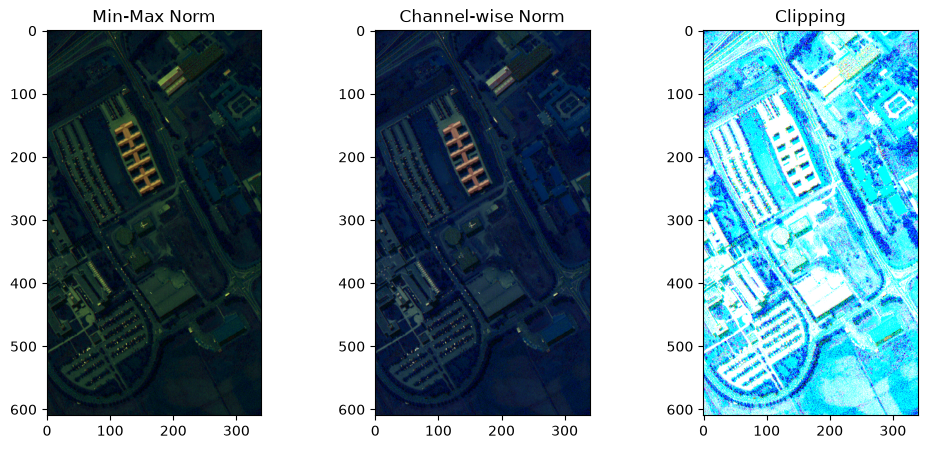

In [24]:
channels = [1, 2, 3]

predicted_image = predict_image()

normalized_images = normalize_images(
    predicted_image,
    channels
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(normalized_images[0])
plt.title("Min-Max Norm")

plt.subplot(1, 3, 2)
plt.imshow(normalized_images[1])
plt.title("Channel-wise Norm")

plt.subplot(1, 3, 3)
plt.imshow(normalized_images[2])
plt.title("Clipping")

plt.show()